# [DRIVE] MATHFI -- DPCN 6 iters + 64 ch + 2hl + 64rt + cbam16 + 50 epochs -- CHASEDB1 (w halfaugs, newDataloader, patching)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/UNet Testing Template src/')
import src.training.metrics as m
print(m)

Mounted at /content/drive
<module 'src.training.metrics' from '/content/drive/MyDrive/UNet Testing Template src/src/training/metrics.py'>


In [2]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [3]:
TITLE = "Base Unet, DPCN, MSU, CBAM, HASSKIP Training Exp for DRIVE dataset -- DPCN 6 iters + 64 ch + 2hl + 64rt + cbam16 + 50 epochs (w halfaugs, newDataloader, patching)"

SAVE_FILE = "[DRIVE] MATHFI_newPatching.pth"

SAVE_DIR = Path("/content/drive/MyDrive/UNet Testing Template src/pth")

DATA_DIR = "/content/drive/MyDrive/Retinal_Vessel_Segmentation_Datasets/DRIVE/"

LABEL_FOLDER = "1st_manual"

PATCH_SIZE = 128

from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet

BASE_KW = {"cbam_reduction": 16}

model_core = DPCNConcatUNet(
    in_ch=1,
    enh_channels=64,
    iters=6,
    threshold_mode="scaled_vat",
    half_life=2.0,
    reduce_to=64,
    base_kwargs=BASE_KW
).to(DEVICE)


# IMPORTS

In [4]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import torch.nn as nn
import torch.nn.functional as F

# --- data utils ---
from src.data.prepare_dataset import (
    build_pairs_for_split,
    build_all_train_pairs,
    assert_dataset_layout,
    sanity_check_sample_alignment,
)
from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs


# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

# SET SEED

In [5]:
SEED = 1337
SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True

# MODEL PARAMS

In [6]:

# param count
print(sum(x.numel() for x in model_core.parameters() if x.requires_grad)/1e6, "M params")

50.694399 M params


# DATALOADERS

In [7]:
# 1) Pairs
train_pairs_full = build_pairs_for_split(DATA_DIR, split="training", label_folder=LABEL_FOLDER)   # 20 imgs
test_pairs       = build_pairs_for_split(DATA_DIR, split="test",     label_folder=LABEL_FOLDER)   # 20 imgs

# 2) Train/Val loaders: let make_loaders do an 80/20 split from training
#    (this is your "validation" during training; NOT the test set)
train_loader, val_loader = make_loaders(
    train_pairs=train_pairs_full,
    val_pairs=None,               # <-- auto 80/20 split from training
    image_size=512,
    batch_size=2,
    num_workers=1,                # Windows/Jupyter: keep 0
    seed=1337,
    strict_fov=True,
    augs_train=get_train_augs(512),
    augs_val=get_val_augs(512),   # deterministic, no random augs

    # NEW: enable patching for TRAIN ONLY
    patch_train=True,
    patch_size=PATCH_SIZE,                 # 256/384 commonly good; must divide model stride
    vessel_bias_p=0.6,              # % of vessel-centered crops
    min_percent_vessel=0.08,               # avoid empty vessel patches
    virtual_mult=20,               # ~how many patches per image per "epoch"
)

# 3) Test loader: separate; same preprocessing as val (no random augs)
_, test_loader = make_loaders(
    train_pairs=test_pairs,       # dummy (ignored) – we just want the second loader built
    val_pairs=test_pairs,         # pass test_pairs so the returned "val" loader = test loader
    image_size=512,
    batch_size=2,
    num_workers=1,
    seed=1337,
    strict_fov=True,
    augs_train=None,              # unused
    augs_val=get_val_augs(512),   # no random augs
    # ensure test is full-image mode
    patch_train=False
)

# LOSS

In [8]:
from src.training.loss_functions import DiceBCEComplementLoss
import torch

# (optional) estimate class weights from a few batches to handle heavy imbalance
def estimate_class_weights(loader, max_batches=20):
    with torch.no_grad():
        s = 0.0; n = 0
        for i, b in enumerate(loader):
            s += b["mask"].float().mean().item()  # foreground fraction in [0,1]
            n += 1
            if i+1 >= max_batches: break
    p = max(1e-6, min(1-1e-6, s / max(1, n)))      # foreground prior
    w1 = 1.0 / p                                    # weight FG inversely to its freq
    w0 = 1.0 / (1.0 - p)                            # weight BG inversely to its freq
    # normalize so w0 + w1 ≈ 2 (keeps scale stable)
    s2 = w0 + w1
    w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
    return w0, w1, p

w0, w1, p = estimate_class_weights(train_loader, max_batches=20)
print(f"~ foreground prior p ≈ {p:.5f} | class weights -> w0={w0:.3f}, w1={w1:.3f}")

loss_fn = DiceBCEComplementLoss(
    w0=w0, w1=w1,
    dice_weight=0.5,         # tune (e.g., 0.6 Dice / 0.4 BCE)
    bce_weight=0.5,
    exact_equation=False,    # keep False so the BCE term is minimized (not added)
    reduction="mean",
)

~ foreground prior p ≈ 0.13662 | class weights -> w0=0.273, w1=1.727


# TRAIN LOOP

In [9]:
VAL_WINDOW  = PATCH_SIZE     # match your patch_size
VAL_OVERLAP = 0.25

@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window=512, overlap=0.5, device="cuda"):
    """
    img_1chw: torch.Tensor [1,1,H,W] on *any* device.
    Returns: averaged logits [1,1,H,W] on 'device'
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    # we'll average *logits* to keep your loss_fn (e.g., BCEWithLogits) unchanged
    acc  = torch.zeros_like(img, device=device)
    norm = torch.zeros_like(img, device=device)

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                logit = model(tile)                            # [1,1,win,win]
            acc[:, :, y0:y1, x0:x1] += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    logits = acc / torch.clamp_min(norm, 1.0)
    return logits

def show_patch_triplet(x_1hw, y_1hw, logits_1hw, title=None):
    x  = x_1hw.squeeze().detach().cpu()
    y  = y_1hw.squeeze().detach().cpu()
    p  = torch.sigmoid(logits_1hw).squeeze().detach().cpu()
    b  = (p >= 0.5).float()

    fig, axs = plt.subplots(1,4, figsize=(10,3))
    axs[0].imshow(x, cmap='gray');      axs[0].set_title('Image');        axs[0].axis('off')
    axs[1].imshow(y, cmap='gray');      axs[1].set_title('GT');           axs[1].axis('off')
    axs[2].imshow(p, cmap='gray');      axs[2].set_title('Prob');         axs[2].axis('off')
    axs[3].imshow(b, cmap='gray');      axs[3].set_title('Pred (0.5)');   axs[3].axis('off')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()



def train_one_epoch(model, loader, optimizer, scaler, loss_fn, epoch, preview_every_epochs):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE,  non_blocking=True)  # [B,1,H,W]

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            loss   = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # ---- preview once every N epochs, only on the first batch
        #saved_preview=False
        #if (preview_every_epochs and (epoch % preview_every_epochs == 0)
        #        and not saved_preview):
        #    i = 0
        #    try:
        #        show_patch_triplet(batch["image"][i:i+1], batch["mask"][i:i+1], logits[i:i+1],
        #               title=f"epoch {epoch}")
        #        saved_preview = True
        #    except Exception as e:
        #        print(f"[debug save skipped] {e}")


        total += loss.item() * x.size(0)
        n     += x.size(0)


    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn, window=512, overlap=0.5, device=DEVICE, use_fov=True):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)  # [B,1,H,W] (full images)
        y = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        for i in range(x.size(0)):
            # stitch logits over full image i
            logits_i = sliding_window_forward_logits(model, x[i:i+1], window=window, overlap=overlap, device=device)
            # restrict loss to FOV (keeps loss fair)
            yi = y[i:i+1]
            if use_fov:
                yi = yi * (fov[i:i+1] > 0.5).float()

            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                loss_i = loss_fn(logits_i, yi)

            total += loss_i.item()
            n     += 1
    return total / max(1, n)



In [10]:
import json, time, math
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import LambdaLR

#model_core.load_state_dict(torch.load(SAVE_DIR / SAVE_FILE, map_location=DEVICE))

# --- optimizer / scaler / scheduler ---
optimizer = torch.optim.AdamW(model_core.parameters(), lr=3e-4, weight_decay=1e-4)
scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))

EPOCHS = 50
warmup_epochs = 5

def lr_lambda(e):
    if e < warmup_epochs:
        return (e + 1) / warmup_epochs
    progress = (e - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val = float("inf")

# --- lists to collect losses for plotting later ---
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    print(f"----- EPOCH {epoch} -----")
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.time()

    tr_loss  = train_one_epoch(model_core, train_loader, optimizer, scaler, loss_fn, epoch=epoch, preview_every_epochs=10)
    val_loss = validate_loss_only(
        model_core, val_loader, loss_fn,
        window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE
    )
    scheduler.step()

    if DEVICE == "cuda": torch.cuda.synchronize()
    print(f"[{epoch:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
          f"lr={optimizer.param_groups[0]['lr']:.3e} time={(time.time()-t0):.1f}s")

    # record
    train_losses.append(float(tr_loss))
    val_losses.append(float(val_loss))

    # checkpoints
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_core.state_dict(), SAVE_DIR / SAVE_FILE)

----- EPOCH 1 -----
[001] train=1.0134 val=0.8873 lr=1.200e-04 time=85.7s
----- EPOCH 2 -----
[002] train=0.7281 val=0.6491 lr=1.800e-04 time=46.4s
----- EPOCH 3 -----
[003] train=0.6182 val=0.5433 lr=2.400e-04 time=49.1s
----- EPOCH 4 -----
[004] train=0.5533 val=0.4729 lr=3.000e-04 time=49.6s
----- EPOCH 5 -----
[005] train=0.5149 val=0.4280 lr=3.000e-04 time=50.3s
----- EPOCH 6 -----
[006] train=0.4845 val=0.4223 lr=2.996e-04 time=49.7s
----- EPOCH 7 -----
[007] train=0.4599 val=0.3829 lr=2.985e-04 time=49.5s
----- EPOCH 8 -----
[008] train=0.4405 val=0.3736 lr=2.967e-04 time=49.0s
----- EPOCH 9 -----
[009] train=0.4629 val=0.3886 lr=2.942e-04 time=50.5s
----- EPOCH 10 -----
[010] train=0.4594 val=0.3507 lr=2.910e-04 time=45.3s
----- EPOCH 11 -----
[011] train=0.4416 val=0.4051 lr=2.870e-04 time=50.4s
----- EPOCH 12 -----
[012] train=0.4384 val=0.4410 lr=2.824e-04 time=45.0s
----- EPOCH 13 -----
[013] train=0.4436 val=0.4059 lr=2.772e-04 time=45.1s
----- EPOCH 14 -----
[014] train=0

# PLOT

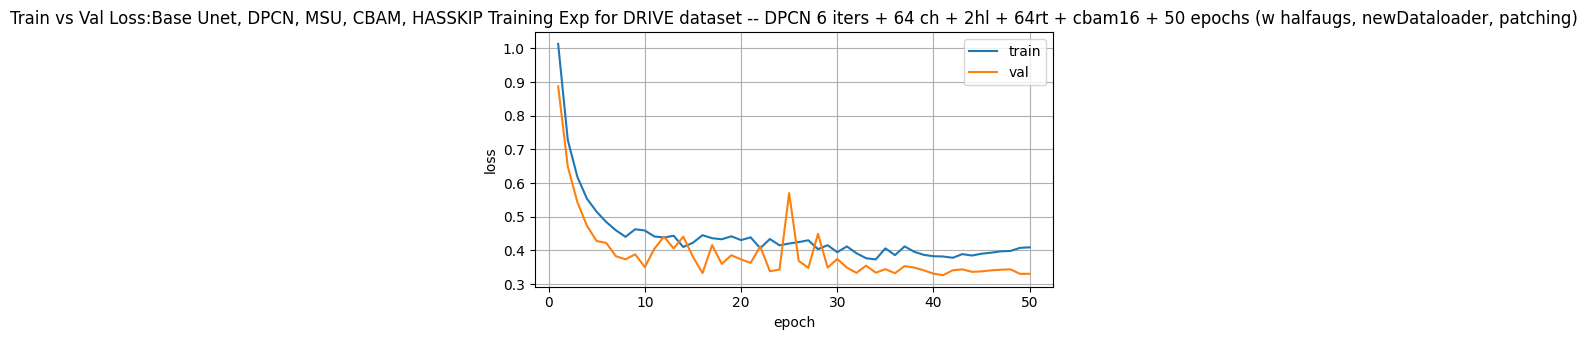

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
plt.title("Train vs Val Loss:" + TITLE)
plt.tight_layout()
plt.show()

# METRICS EVAL

In [16]:
#SAVE_FILE = "[DRIVE] MATHFI_newPatching.pth"
#
#torch.save(model_core.state_dict(), SAVE_DIR / SAVE_FILE)

In [15]:
# load best
#model_core.load_state_dict(torch.load(SAVE_DIR / SAVE_FILE, map_location=DEVICE))
model_for_eval = model_core.eval()

# run your evaluation utility
print(TITLE)
evaluate_and_print(model_for_eval, test_dataloader=test_loader, device=DEVICE, threshold=0.5, compute_auc=True)

Base Unet, DPCN, MSU, CBAM, HASSKIP Training Exp for DRIVE dataset -- DPCN 6 iters + 64 ch + 2hl + 64rt + cbam16 + 50 epochs (w halfaugs, newDataloader, patching)
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8184
Specificity    : 0.9834
clDice         : 0.8224
Accuracy       : 0.9692
Dice           : 0.8175
IoU            : 0.6916
Precision      : 0.8208
FPR            : 0.0166
FDR            : 0.1792
Dice_thin      : 0.5369
Dice_thick     : 0.6881
ROC_AUC        : 0.9849
PR_AUC         : 0.9051
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8160
Specificity    : 0.9834
F1/Dice        : 0.8180
Accuracy       : 0.9692
IoU            : 0.6921
Precision      : 0.8200
FPR            : 0.0166
FDR            : 0.1800
ROC_AUC        : 0.9843
PR_AUC         : 0.9024


# VISUALIZATION

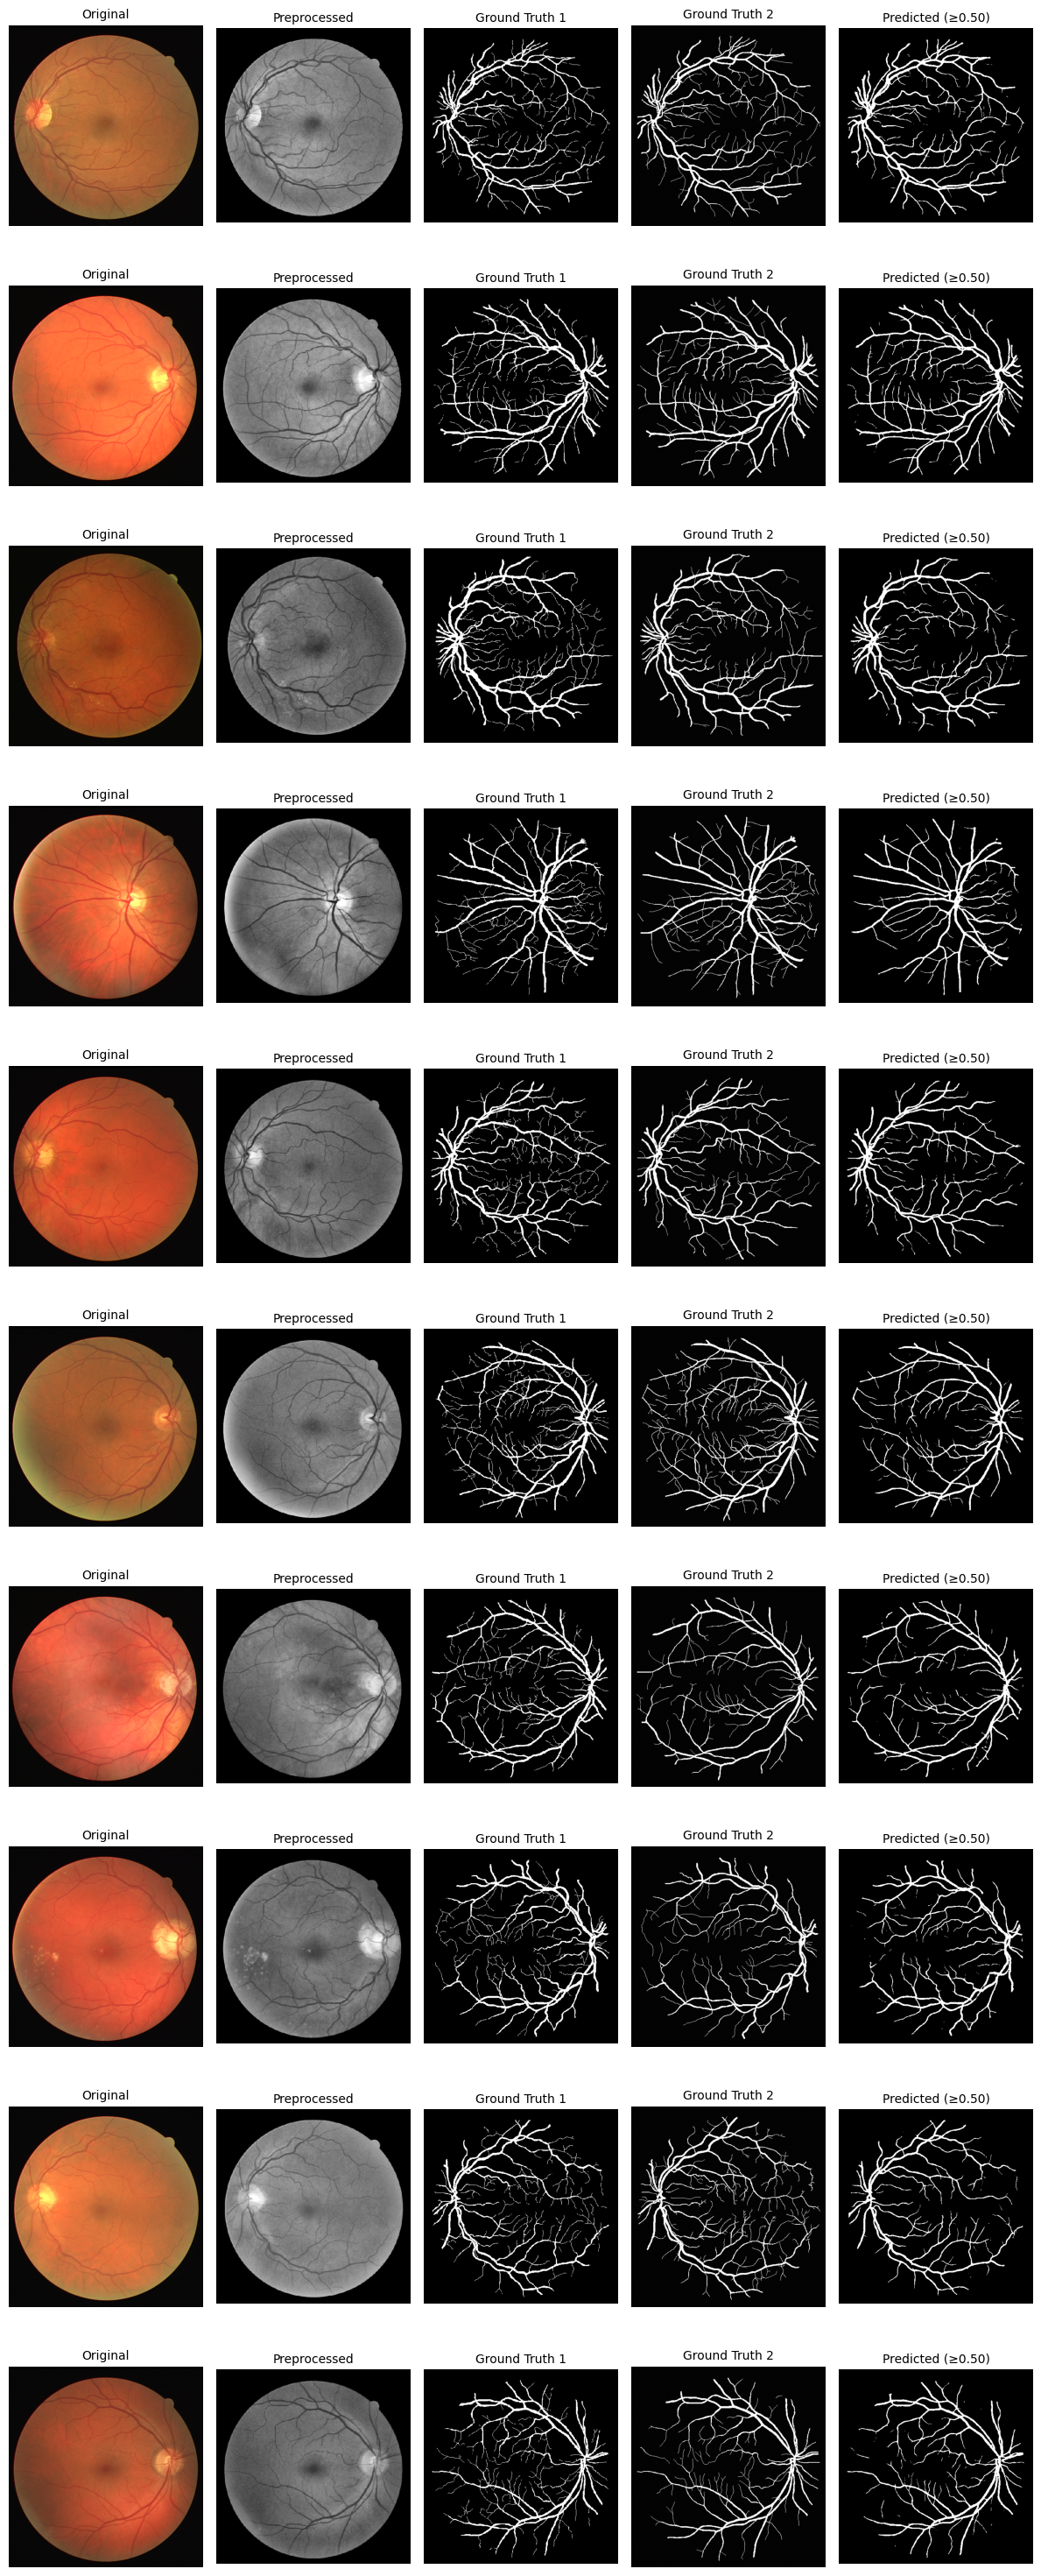

In [14]:
visualize_samples(
    model=model_for_eval,
    dataloader=test_loader,
    n_rows=10,
    device=DEVICE,
    threshold=0.5,
    clamp_pred_with_fov=True,
    figsize_per_row=(12, 3),
)